Individual Fairness - Regression
- Data California Housing Data
- Lipschitz fairness: 비슷한 입력이면 비슷한 예측값
- Fair loss 포함 vs 미포함 → 예측 일관성 + 평균 차이 비교
- 입력 유사도별 예측값 차이 비교 (히트맵 / 분포도 등)


In [1]:
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_squared_error

# 데이터 로드
housing = fetch_california_housing()
X, y = housing.data[:100], housing.target[:100]
# 가상의 민감 속성 생성 (중간 소득 기준으로 이진화)
median_income = X[:, 0]  # 첫 번째 특성이 중간 소득
S = (median_income > np.median(median_income)).astype(int)

# 데이터 분리
X_train, X_test, y_train, y_test, S_train, S_test = train_test_split(X, y, S, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid, S_train, S_valid = train_test_split(X_train, y_train, S_train, test_size=0.2, random_state=42)

# 데이터 표준화
scaler_reg = StandardScaler()
X_train = scaler_reg.fit_transform(X_train)
X_test = scaler_reg.transform(X_test)

# Tensor 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
S_train_t = torch.tensor(S_train, dtype=torch.int32)

X_valid_t = torch.tensor(X_valid, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid, dtype=torch.float32).view(-1, 1)
S_valid_t = torch.tensor(S_valid, dtype=torch.int32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
S_test_t = torch.tensor(S_test, dtype=torch.int32)


In [4]:
# 3. 기본 회귀 모델
class Regressor(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(input_dim, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )
  def forward(self, x):
    return self.model(x)

# 4. Lipschitz-based Fairness Loss
def lipschitz_fairness_loss(fx, X, L=10.0):
  # 유사한 샘플쌍 만들기
  pairwise_loss = 0
  count = 0
  for i in range(len(X)):
    for j in range(i+1, len(X)):
      xi, xj = X[i], X[j]
      fi, fj = fx[i], fx[j]
      d = torch.norm(xi - xj) + 1e-6  # 입력 거리
      diff = torch.abs(fi - fj)       # 예측값 차이
      violation = torch.relu(diff - L * d)  # 위반한 만큼만
      pairwise_loss += violation
      count += 1
  return pairwise_loss / count


In [5]:
# 5. 학습 함수
def train_model(use_fairness=False, lambda_fair=0.5, epochs=10):
  model = Regressor(X_train.shape[1])
  optimizer = optim.Adam(model.parameters(), lr=0.01)
  loss_fn = nn.MSELoss()

  best_model = None
  best_val_loss = float('inf')

  for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    model.train()
    y_pred = model(X_train_t)
    loss = loss_fn(y_pred, y_train_t)

    # fairness penalty 추가
    if use_fairness:
      loss += lambda_fair * lipschitz_fairness_loss(y_pred, X_train_t).squeeze()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # validation loss 측정
    model.eval()
    with torch.no_grad():
      val_pred = model(X_valid_t)
      val_loss = loss_fn(val_pred, y_valid_t)
      if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model

  return best_model

In [6]:
# 6. 두 모델 학습 (공정성 적용 전후)
model_normal = train_model(use_fairness=False)
model_fair = train_model(use_fairness=True)

Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10
Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


In [7]:
# 7. 성능 비교
from sklearn.metrics import accuracy_score, mean_squared_error
def evaluate(model, name):
  model.eval()
  with torch.no_grad():
    preds = model(X_test_t).squeeze().numpy()
  real = y_test_t.squeeze().numpy()
  mse = mean_squared_error(real, preds)
  print(f"{name} MSE: {mse:.4f}")
  return preds

pred_normal = evaluate(model_normal, "No Fairness")
pred_fair = evaluate(model_fair, "With Fairness")

No Fairness MSE: 0.4764
With Fairness MSE: 0.5531


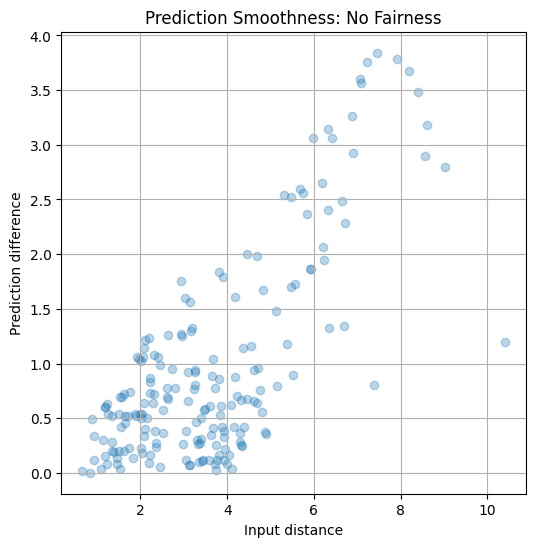

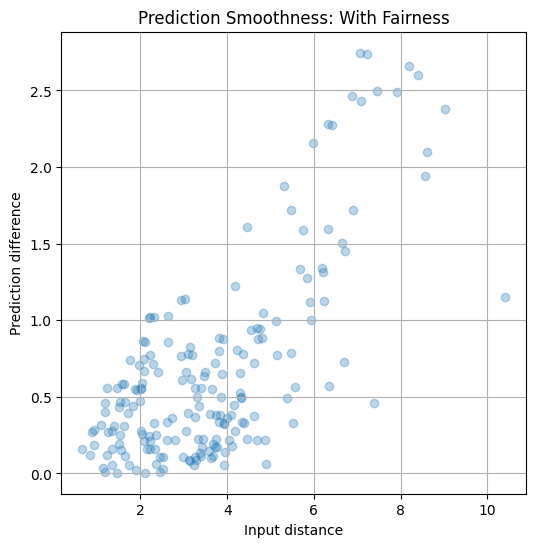

In [8]:
# 8. 시각화 (예측값 차이 vs 입력 유사도)

# =======================================
#   d_Y(f(x_i), f(x_j)) ≤ L * d_X(x_i, x_j)
#
#   - d_X: 입력 공간에서의 거리 (유사도)
#   - d_Y: 출력(예측값) 차이
# =======================================

def plot_similarity(pred1, pred2, model_name):
  diffs = [] # 출력 차이 (|f(x_i) - f(x_j)|)
  dists = [] # 입력 거리 (||x_i - x_j||)
  # 모든 샘플 쌍 (i, j)에 대해 pairwise 비교 수행
  # individual fairness는 "개인 간 비교"이므로 pairwise 계산 필수
  # 입력 거리 계산 (유사도)
  # Euclidean distance:
  #   d_X(x_i, x_j) = ||x_i - x_j||_2
  #
  # 값이 작을수록:
  #   → 두 사람은 feature space에서 "유사한 개인"
  # ----------------------------------------------------
  for i in range(len(X_test)):
    for j in range(i+1, len(X_test)):
      input_dist = np.linalg.norm(X_test[i] - X_test[j])
      output_diff = abs(pred1[i] - pred1[j])
      dists.append(input_dist)
      diffs.append(output_diff)

  plt.figure(figsize=(6, 6))
  plt.scatter(dists, diffs, alpha=0.3)
  plt.xlabel("Input distance")
  plt.ylabel("Prediction difference")
  plt.title(f"Prediction Smoothness: {model_name}")
  plt.grid(True)
  plt.show()

plot_similarity(pred_normal, pred_normal, "No Fairness")
plot_similarity(pred_fair, pred_fair, "With Fairness")


Fairncess Datasets
1. Data Adult Income Dataset
  - 목표: 연소득 50K 이상 예측 (Binary classification)
  - 주요 민감속성: sex, race
  - fairlearn 사용

2. COMPAS Dataset
  - 목표: 재범 위험도 예측 (Binary classification)
  - 주요 민감속성: race, sex
  - https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv
  
